# Physics-Informed Neural Networks (PINNs) with Sorix
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mitchell-Mirano/sorix/blob/develop/docs/examples/pde/heat_equation_pinn.ipynb)
[![Open in GitHub](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/Mitchell-Mirano/sorix/blob/develop/docs/examples/pde/heat_equation_pinn.ipynb)
[![Open in Docs](https://img.shields.io/badge/Open%20in-Docs-blue?logo=readthedocs)](https://mitchell-mirano.github.io/sorix/examples/pde/heat-equation-pinn/)


Physics-Informed Neural Networks (PINNs) represent a groundbreaking approach to solving Partial Differential Equations (PDEs) by embedding the underlying physical laws directly into the neural network's loss function. This allows for deep learning models that not only fit the data but also satisfy the physical constraints of the problem.

In this notebook, we'll implement a PINN to solve the one-dimensional **Heat Equation** using the `sorix` library and its functional `sorix.autograd.grad` interface for high-order differentiation.


In [ ]:
# Uncomment the next line and run this cell to install sorix
#!pip install 'sorix @ git+https://github.com/Mitchell-Mirano/sorix.git@develop'

## 1. What are PINNs?

A PINN is essentially a standard neural network $ u_\theta(x, t) $ parameterized by $ \theta $. However, instead of training it only on labeled data (Initial and Boundary Conditions), we also penalize the network if it violates the PDE across a set of points in the domain called **collocation points**.

The total loss is:

$$ \mathcal{L} = \mathcal{L}_{BC} + \mathcal{L}_{IC} + \mathcal{L}_{physics} $$

Where:
- $ \mathcal{L}_{BC} $: Loss from Boundary Conditions.
- $ \mathcal{L}_{IC} $: Loss from Initial Conditions.
- $ \mathcal{L}_{physics} = \text{MSE}(R(x, t), 0) $, where $ R $ is the residual of the PDE calculated via automatic differentiation.


## 2. The 1D Heat Equation (Enhanced Wave)

We aim to find $ u(x, t) $ that satisfies:

$$ \frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} $$

Over the domain $ x \in [0, 1] $ and $ t \in [0, 5] $.

### **Conditions:**
- **Boundary Conditions (BC)**: $ u(0, t) = u(1, t) = 0 $
- **Initial Condition (IC)**: $ u(x, 0) = \sin(2\pi x) $

### **Analytical Solution:**
Given the diffusion coefficient $ \alpha = 0.01 $, the analytical solution is:

$$ u(x, t) = e^{-\alpha (2\pi)^2 t} \sin(2\pi x) $$


In [1]:
import numpy as np
import sorix
from sorix import tensor, grad, no_grad, cat
import sorix.nn as nn
import sorix.optim as optim
from sorix.utils import math as sm
import matplotlib.pyplot as plt

# Constants
alpha = 0.01
freq = 3.0
device = 'cpu'


## 3. Defining the Model

A deeper MLP to handle the higher frequency spatial variation.


In [2]:
class PINN(nn.Module):
    """Neural Network for PINN"""
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        
    def __call__(self, x_t):
        return self.net(x_t)


## 4. Physics-Informed Loss


In [3]:
def physics_residual(model, x, t, alpha=0.01):
    """Computes the PDE residual R = du/dt - alpha * d2u/dx2"""
    x_t = cat([x, t], axis=1)
    u = model(x_t)
    
    # Higher order derivatives require create_graph=True
    du_dxt = grad(u, x_t, grad_outputs=sorix.ones_like(u), create_graph=True)[0]  # [N, 2] -> [du/dx, du/dt]
    
    du_dx = du_dxt[:, 0].reshape(-1, 1)
    du_dt = du_dxt[:, 1].reshape(-1, 1)
    
    # Second derivative w.r.t x: d2u/dx2
    d2u_dx2 = grad(du_dx, x_t, grad_outputs=sorix.ones_like(du_dx), create_graph=True)[0][:, 0].reshape(-1, 1)
    
    residual = du_dt - alpha * d2u_dx2
    return residual


## 5. Generating Training Data (Extended Horizon)

We extend the time horizon to $t=5$ and increase sample density for the $2\pi$ wave.


In [4]:
np.random.seed(42)
t_max = 5.0

# BC: x=0 and x=1, t randomly sampled in [0, t_max]
t_bc = tensor(np.random.rand(200, 1) * t_max, requires_grad=True)
x_bc_0 = tensor(np.zeros((200, 1)), requires_grad=True)
x_bc_1 = tensor(np.ones((200, 1)), requires_grad=True)

# IC: t=0, x randomly sampled
x_ic = tensor(np.random.rand(200, 1), requires_grad=True)
t_ic = tensor(np.zeros((200, 1)), requires_grad=True)
u_ic_target = sm.sin(freq * np.pi * x_ic.data) # Analytical sin(2*pi*x)

# Collocation points for PDE
x_col = tensor(np.random.rand(2000, 1), requires_grad=True)
t_col = tensor(np.random.rand(2000, 1) * t_max, requires_grad=True)


## 6. Training Loop


In [5]:
model = PINN(hidden_dim=64)
# Use a lower learning rate for stability with higher frequency waves
optimizer = optim.Adam(model.parameters(), lr=5e-4)
mse = nn.MSELoss()

epochs = 3000
history = []

for epoch in range(epochs + 1):
    optimizer.zero_grad()
    
    # 1. Boundary Condition Loss
    u_bc_0 = model(cat([x_bc_0, t_bc], axis=1))
    u_bc_1 = model(cat([x_bc_1, t_bc], axis=1))
    loss_bc = mse(u_bc_0, tensor(0.0)) + mse(u_bc_1, tensor(0.0))
    
    # 2. Initial Condition Loss
    u_ic = model(cat([x_ic, t_ic], axis=1))
    loss_ic = mse(u_ic, tensor(u_ic_target))
    
    # 3. Physics Residual Loss
    residual = physics_residual(model, x_col, t_col, alpha=alpha)
    loss_physics = mse(residual, tensor(0.0))
    
    # Total Loss (Weighted physics loss slightly higher to ensure PDE capture)
    loss = loss_bc + loss_ic + 2.0 * loss_physics
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        lv = loss.item() if hasattr(loss, 'item') else loss.data
        print(f"Epoch {epoch:5d} | Loss: {lv:.6f} | Physics: {loss_physics.item():.6f}")
    history.append(loss.item())


Epoch     0 | Loss: 1.674646 | Physics: 0.105330
Epoch   500 | Loss: 0.185051 | Physics: 0.013323
Epoch  1000 | Loss: 0.009037 | Physics: 0.001876
Epoch  1500 | Loss: 0.001130 | Physics: 0.000371
Epoch  2000 | Loss: 0.000532 | Physics: 0.000194
Epoch  2500 | Loss: 0.000361 | Physics: 0.000141
Epoch  3000 | Loss: 0.000271 | Physics: 0.000112


## 7. Results and Comparison (Longitudinal Evolution)

Let's visualize how the heat wave $\sin(2\pi x)$ evolves over the extended time horizon $t \in [0, 5]$.


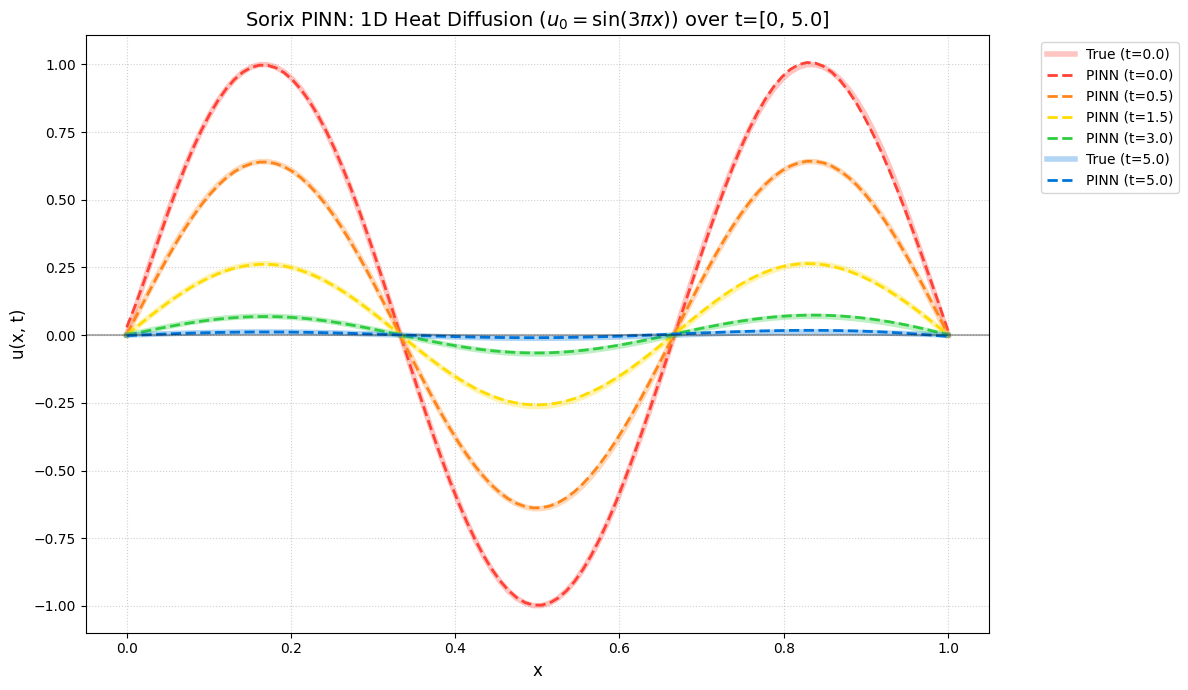

In [6]:
test_x = np.linspace(0, 1, 100).reshape(-1, 1)
time_steps = [0.0, 0.5, 1.5, 3.0, 5.0]
colors = ['#FF4136', '#FF851B', '#FFDC00', '#2ECC40', '#0074D9']

plt.figure(figsize=(12, 7))

for i, t_val in enumerate(time_steps):
    test_t = np.ones_like(test_x) * t_val
    
    # Analytical Solution: u(x, t) = exp(-alpha * (freq*pi)^2 * t) * sin(freq*pi * x)
    u_true = np.exp(-alpha * (freq * np.pi)**2 * t_val) * np.sin(freq * np.pi * test_x)
    
    # PINN prediction
    with no_grad():
        u_pred = model(tensor(np.column_stack((test_x, test_t)))).numpy()
    
    plt.plot(test_x, u_true, '-', color=colors[i], alpha=0.3, linewidth=4, label=f"True (t={t_val})" if i==0 or i==4 else None)
    plt.plot(test_x, u_pred, '--', color=colors[i], linewidth=2, label=f"PINN (t={t_val})")

plt.title(fr"Sorix PINN: 1D Heat Diffusion ($u_0 = \sin({int(freq)}\pi x)$) over t=[0, 5.0]", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("u(x, t)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(0, color='black', alpha=0.3)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## Conclusion

By adopting a higher frequency initial condition $ u(x, 0) = \sin(2\pi x) $ and extending the time horizon to $ t=5 $, we can clearly see the dynamics of the heat equation. The spatial wave (with both positive and negative peaks) flattens towards the equilibrium state $ u=0 $. The PINN successfully tracks these complex dynamics across the entire domain, demonstrating Sorix's robustness for solving time-dependent partial differential equations with complex boundary and initial conditions.
